In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler , LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge ,Lasso, ElasticNet , SGDRegressor,LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV ,TimeSeriesSplit, train_test_split
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Milestone Codes 

In [3]:
# #milestone 2 -Q1
# booknow_booking_df['show_datetime'] = pd.to_datetime(booknow_booking_df['show_datetime'])
# booknow_booking_df['booking_datetime'] = pd.to_datetime(booknow_booking_df['booking_datetime'])

# same_day_bookings = booknow_booking_df[
#     booknow_booking_df['show_datetime'].dt.date == booknow_booking_df['booking_datetime'].dt.date
# ]

# total_same_day = same_day_bookings.shape[0]
# print("Total booking records made on the same calendar day as the show's date:", total_same_day)


In [4]:
# #milestone 2 -Q3
# booknow_booking_df['booking_datetime'] = pd.to_datetime(booknow_booking_df['booking_datetime'])
# booknow_booking_df['booking_day'] = booknow_booking_df['booking_datetime'].dt.day_name()
# sunday_bookings = booknow_booking_df[booknow_booking_df['booking_day'] == 'Sunday'].shape[0]
# total_bookings = booknow_booking_df.shape[0]

# percentage_sunday = (sunday_bookings / total_bookings) * 100
# print(f"Percentage of bookings made on Sunday: {percentage_sunday:.2f}%")


In [5]:
# # for milestone 1
# booknow_booking_df['show_datetime'] = pd.to_datetime(booknow_booking_df['show_datetime'])

# earliest_date = booknow_booking_df['show_datetime'].min()
# latest_date = booknow_booking_df['show_datetime'].max()\

# print(earliest_date)
# print(latest_date)

In [6]:
# # milestone 5 Q1 
# booknow_booking_df['show_date'] = pd.to_datetime(booknow_booking_df['show_datetime']).dt.date
# grouped_df = booknow_booking_df.groupby(['book_theater_id', 'show_date'], as_index=False)['tickets_booked'].sum()
# grouped_df.shape

In [7]:
#milestone 2 - Q4
# drama_theaters = booknow_theaters_df[booknow_theaters_df['theater_type'] == 'Drama']
# mean_latitude_drama = drama_theaters['latitude'].mean()
# print("Imputation value (mean latitude of Drama theaters):", mean_latitude_drama)

In [8]:
# #milestone 2 -Q5
# max_lat = booknow_theaters_df['latitude'].max()
# min_lat = booknow_theaters_df['latitude'].min()
# latitude_range = max_lat - min_lat
# latitude_range_rounded = round(latitude_range, 4)
# print("Range of latitude:", latitude_range_rounded)

In [9]:
# #milestone 4 - Q1
# booknow_visits_df["show_date"] = pd.to_datetime(booknow_visits_df["show_date"])
# booknow_visits_df["day"] = booknow_visits_df["show_date"].dt.day
# booknow_visits_df["month"] = booknow_visits_df["show_date"].dt.month
# booknow_visits_df["year"] = booknow_visits_df["show_date"].dt.year
# booknow_visits_df["dayofyear"] = booknow_visits_df["show_date"].dt.dayofyear

# booknow_visits_df.drop('show_date',axis=1,inplace=True)

# X = booknow_visits_df.drop('audience_count',axis=1)
# y = booknow_visits_df['audience_count']

# split_index = int(len(X)*0.8)
# X_train , X_test = X.iloc[:split_index],X.iloc[split_index:]
# y_train , y_test = y.iloc[:split_index], y.iloc[split_index:]

# num_cols = ['day', 'month', 'year', 'dayofyear']
# cat_cols = ['book_theater_id']

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', MinMaxScaler(), num_cols),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        
#     ]
# )

# X_train_processed = preprocessor.fit_transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

# dt = DecisionTreeRegressor(random_state=42)
# dt.fit(X_train_processed,y_train)
# y_train_pred = dt.predict(X_train_processed)
# r2_train = r2_score(y_train,y_train_pred)
# print("R2 score on training data:", round(r2_train, 3))

In [10]:
# # for milestone 1 
# booking_merged = pd.merge(
#     booknow_booking_df,
#     booknow_theaters_df,
#     on='book_theater_id',
#     how='inner'  
# )
# print(booking_merged.shape)

In [11]:
# booking_merged['theater_area'].nunique()

In [12]:
# #milestone 4 - Q2
# y_test_pred = dt.predict(X_test_processed)
# r2_test = r2_score(y_test, y_test_pred)
# print("R2 score on test data:", round(r2_test, 3))

In [13]:
# #milestone 4 - Q3
# param_grid = {
#     'max_depth': [None, 3, 5, 10],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# tscv = TimeSeriesSplit(n_splits=5)
# grid_search = GridSearchCV(
#     estimator=dt,
#     param_grid=param_grid,
#     cv=tscv,
#     scoring='r2',
#     n_jobs=-1
# )
# grid_search.fit(X_train_processed, y_train)
# print("Best Parameters:", grid_search.best_params_)

In [14]:
# #milestone 4 - Q4
# bag_model = BaggingRegressor(random_state=42)
# bag_model.fit(X_train_processed, y_train)
# y_train_pred = bag_model.predict(X_train_processed)
# rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
# print("RMSE on training data:", round(rmse_train, 3))

In [15]:
# y_test_pred = bag_model.predict(X_test_processed)
# rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
# print("RMSE on test data:", round(rmse_test, 3))

In [16]:
# # milestone 3 -Q1
# booknow_visits_df["show_date"] = pd.to_datetime(booknow_visits_df["show_date"])
# booknow_visits_df["day"] = booknow_visits_df["show_date"].dt.day
# booknow_visits_df["month"] = booknow_visits_df["show_date"].dt.month
# booknow_visits_df["year"] = booknow_visits_df["show_date"].dt.year
# booknow_visits_df["dayofyear"] = booknow_visits_df["show_date"].dt.dayofyear
# # Drop the original 'show_date' column
# booknow_visits_df.drop(columns=["show_date"], inplace=True)
# X = booknow_visits_df.drop(columns=["audience_count"])
# y = booknow_visits_df["audience_count"]
# #Time-based split
# split_index = int(len(booknow_visits_df) * 0.8)
# X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
# y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
# X_train.shape

In [17]:
# #milestone3 -Q2
# categorical_cols = ["book_theater_id"]
# numeric_cols = ["day", "month", "year", "dayofyear"]
# preprocessor = ColumnTransformer([
#     ("num", MinMaxScaler(), numeric_cols),
#     ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
# ])
# X_train_transformed = preprocessor.fit_transform(X_train)
# X_test_transformed = preprocessor.transform(X_test)
# model = LinearSVR(random_state=42)
# model.fit(X_train_transformed, y_train)

# y_pred = model.predict(X_test_transformed)
# r2 = r2_score(y_test, y_pred)
# print("R² Score on Test Dataset:", round(r2, 5))

In [18]:
# #milestone 3 -Q3
# svd = TruncatedSVD(n_components=4, random_state=42)
# X_train_svd = svd.fit_transform(X_train_transformed)
# X_test_svd = svd.transform(X_test_transformed)

# svr_model = LinearSVR(random_state=42)
# svr_model.fit(X_train_svd, y_train)

# y_train_pred = svr_model.predict(X_train_svd)

# mae_train = mean_absolute_error(y_train, y_train_pred)

# print("Mean Absolute Error on Training Data:", round(mae_train, 3))

In [19]:
# #milestone 3-Q4
# y_test_pred = svr_model.predict(X_test_svd)
# r2_test = r2_score(y_test, y_test_pred)
# print("R² Score on Test Data:", round(r2_test, 3))

In [20]:
# #milestone 3-Q5
# selector = SelectKBest(score_func=mutual_info_regression, k=2)
# X_train_selected = selector.fit_transform(X_train_transformed, y_train)
# scores = selector.scores_

# max_score = scores.max()
# print("Maximum Score from SelectKBest:", round(max_score, 3))

In [21]:
# #milestone -Q6
# mean_score = scores.mean()

# print("Mean Score from SelectKBest:", round(mean_score, 3))


In [22]:
# #milestone 5 Q2
# cinePOS_booking_df['show_date'] = pd.to_datetime(cinePOS_booking_df['show_datetime']).dt.date
# grouped_cinePOS = cinePOS_booking_df.groupby(
#     ['cine_theater_id', 'show_date'], as_index=False
# )['tickets_sold'].sum()
# grouped_cinePOS.shape

In [23]:
# #milestone 2 -Q6
# cinePOS_booking_df['show_datetime'] = pd.to_datetime(cinePOS_booking_df['show_datetime'])
# cinePOS_booking_df['booking_datetime'] = pd.to_datetime(cinePOS_booking_df['booking_datetime'])
# percentile_95 = cinePOS_booking_df['tickets_sold'].quantile(0.95)
# print("95th percentile of tickets_sold:", percentile_95)

In [24]:
# #milestone 2 -Q7
# categorical_cols = ['theater_type', 'theater_area']
# cinePOS_theaters_encoded = pd.get_dummies(
#     cinePOS_theaters_df, 
#     columns=categorical_cols, 
#     drop_first=False  )


# print("Shape after OneHot Encoding:", cinePOS_theaters_encoded.shape)

In [25]:
# #milestone 2 -Q2
# date_info_df['show_date'] = pd.to_datetime(date_info_df['show_date'])
# date_info_df['year_month'] = date_info_df['show_date'].dt.to_period('M')
# unique_months = date_info_df['year_month'].nunique()
# print("Total unique calendar months in show_date:", unique_months)

In [26]:
# #milestone 5 Q3
# booknow_booking_df['show_date'] = pd.to_datetime(booknow_booking_df['show_datetime']).dt.date
# cinePOS_booking_df['show_date'] = pd.to_datetime(cinePOS_booking_df['show_datetime']).dt.date
# book_grouped = booknow_booking_df.groupby(['book_theater_id', 'show_date'], as_index=False)['tickets_booked'].sum()
# cine_grouped = cinePOS_booking_df.groupby(['cine_theater_id', 'show_date'], as_index=False)['tickets_sold'].sum()
# merged_book = pd.merge(book_grouped,movie_theater_id_relation_df,on='book_theater_id',how='left')
# combined_df = pd.merge(merged_book,cine_grouped,on=['cine_theater_id', 'show_date'],how='outer')
# combined_df['movie_theater_id'] = combined_df['book_theater_id'].combine_first(combined_df['cine_theater_id'])
# combined_df = combined_df[['movie_theater_id', 'show_date', 'tickets_booked', 'tickets_sold']]

# combined_df.shape

In [27]:
# #milestone 5 Q4
# merged_final = pd.merge(combined_df,booknow_visits_df,left_on=['movie_theater_id', 'show_date'],right_on=['book_theater_id', 'show_date'],how='left')
# merged_final.drop(columns=['book_theater_id'], inplace=True, errors='ignore')
# merged_final = merged_final.sort_values(by=['movie_theater_id', 'show_date'])

# merged_final['prev_day_audience_count'] = merged_final.groupby('movie_theater_id')['audience_count'].shift(1)
# missing_count = merged_final['prev_day_audience_count'].isna().sum()
# missing_count

In [28]:
# #milestone 5 Q5
# theater_data = booknow_visits_df[booknow_visits_df['book_theater_id'] == 'book_00001'].copy()
# theater_data = theater_data.sort_values('show_date')
# series = theater_data['audience_count']
# adf_result = adfuller(series)

# p_value = adf_result[1]
# p_value

In [29]:
# #milestone 5 Q7
# theater_data = booknow_visits_df[booknow_visits_df['book_theater_id'] == 'book_00001'].copy()
# theater_data = theater_data.sort_values('show_date')
# theater_data['show_date'] = pd.to_datetime(theater_data['show_date'])

# theater_data.set_index('show_date', inplace=True)

# train = theater_data.iloc[:-30]
# test = theater_data.iloc[-30:]
# model = ARIMA(train['audience_count'], order=(1,1,1))
# fitted_model = model.fit()

# print(fitted_model.summary())

# # No.Observations are 312 so the training data will contains (Total records − 30 = 342 − 30 = 312)


In [30]:
# #milestone 5 Q10
# forecast = fitted_model.forecast(steps=30)

# r2 = r2_score(test['audience_count'], forecast)
# r2

In [31]:
# # for milestone 1 
# df1 = pd.merge(
#     movie_theater_id_relation_df,
#     cinePOS_booking_df,
#     on='cine_theater_id',
#     how='inner'   
# )
# combined_df = pd.merge(
#     df1,
#     cinePOS_theaters_df,
#     on='cine_theater_id',
#     how='inner'
# )

In [32]:
# # for milestone 1 
# missing_columns = combined_df.columns[combined_df.isnull().any()].tolist()

# missing_columns_str = ','.join(missing_columns)
# print(missing_columns_str)


In [33]:
# # for milestone 1
# sample_submission['date'] = sample_submission['ID'].apply(lambda x: x.split('_')[-1])
# sample_submission['date'] = pd.to_datetime(sample_submission['date'])

# earliest_date = sample_submission['date'].min()
# latest_date = sample_submission['date'].max()

# print(earliest_date)
# print(latest_date)

# Data Loading and Structure Understanding 

In [34]:
booknow_booking_df = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')

# This dataframe contains information about when and how many tickets were booked for a book_theater_id of what showtime.

In [35]:
print(f'This is the shape of the booknow_booking_df{booknow_booking_df.shape}')

This is the shape of the booknow_booking_df(68336, 4)


In [36]:
print(booknow_booking_df.isna().sum())

book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64


In [37]:
booknow_booking_df.head()

,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


In [38]:
booknow_booking_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


In [39]:
booknow_theaters_df = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
# This dataframe tells you about the type of the theater,area ,latitude and longitude

In [40]:
booknow_theaters_df['theater_type'].value_counts()

theater_type
Other     411
Comedy    196
Drama     183
Action     39
Name: count, dtype: int64

In [41]:
print(f'This is the shape of the booknow_theaters_df{booknow_theaters_df.shape}')

This is the shape of the booknow_theaters_df(829, 5)


In [42]:
print(booknow_theaters_df.isna().sum())

book_theater_id    515
theater_type         0
theater_area         0
latitude             0
longitude            0
dtype: int64


In [43]:
booknow_theaters_df.head()

,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017
3,book_00258,Drama,Area_001,22.619233,78.113017
4,book_00212,Drama,Area_002,23.004410,79.934515


In [44]:
booknow_theaters_df['theater_type'].value_counts()


theater_type
Other     411
Comedy    196
Drama     183
Action     39
Name: count, dtype: int64

In [45]:
booknow_theaters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


In [46]:
booknow_visits_df = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
#This dataframe will tell the audience count for a particular show_date in the theater.

In [47]:
print(f'This is the shape of the booknow_visits_df{booknow_visits_df.shape}')

This is the shape of the booknow_visits_df(214046, 3)


In [48]:
print(booknow_visits_df.isna().sum())

book_theater_id    0
show_date          0
audience_count     0
dtype: int64


In [49]:
booknow_visits_df.head()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


In [50]:
booknow_visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214046 non-null  object
 1   show_date        214046 non-null  object
 2   audience_count   214046 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB


In [51]:
cinePOS_booking_df = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
#This dataframe will tell the tickets booked vis POS

In [52]:
print(f'This is the shape of the cinePOS_booking_df{cinePOS_booking_df.shape}')

This is the shape of the cinePOS_booking_df(1641966, 4)


In [53]:
print(cinePOS_booking_df.isna().sum())

cine_theater_id     0
show_datetime       0
booking_datetime    0
tickets_sold        0
dtype: int64


In [54]:
cinePOS_booking_df.head()

,cine_theater_id,show_datetime,booking_datetime,tickets_sold
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3
2,cinePOS_00003,2023-01-01 16:00:00,2023-01-01 14:00:00,2
3,cinePOS_00004,2023-01-01 17:00:00,2023-01-01 11:00:00,5
4,cinePOS_00005,2023-01-01 17:00:00,2023-01-01 03:00:00,13


In [55]:
cinePOS_booking_df['show_datetime'].isna().sum()

0

In [56]:
cinePOS_booking_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   cine_theater_id   1641966 non-null  object
 1   show_datetime     1641966 non-null  object
 2   booking_datetime  1641966 non-null  object
 3   tickets_sold      1641966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ MB


In [57]:
cinePOS_theaters_df = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
# This dataframe tells you about the type of the theater,area ,latitude and longitude

In [58]:
print(f'This is the shape of the cinePOS_theaters_df{cinePOS_theaters_df.shape}')

This is the shape of the cinePOS_theaters_df(4690, 5)


In [59]:
cinePOS_theaters_df.head()

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


In [60]:
cinePOS_theaters_df['theater_type'].unique()

array(['Other', 'Drama', 'Action'], dtype=object)

In [61]:
cinePOS_theaters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cine_theater_id  4690 non-null   object 
 1   theater_type     4690 non-null   object 
 2   theater_area     4690 non-null   object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


In [62]:
date_info_df = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
# This dataframe provides the information about the day_of_week for the show date

In [63]:
print(f'This is the shape of the date_info_df{date_info_df .shape}')

This is the shape of the date_info_df(547, 2)


In [64]:
print(date_info_df.isna().sum())

show_date      0
day_of_week    0
dtype: int64


In [65]:
date_info_df.head()

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


In [66]:
date_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   show_date    547 non-null    object
 1   day_of_week  547 non-null    object
dtypes: object(2)
memory usage: 8.7+ KB


In [67]:
movie_theater_id_relation_df = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')
# This dataframe have book_theater_id and cine_theater_id 

In [68]:
print(f'This is the shape of the booknow_booking_df{movie_theater_id_relation_df.shape}')

This is the shape of the booknow_booking_df(150, 2)


In [69]:
print(movie_theater_id_relation_df.isna().sum())

book_theater_id    0
cine_theater_id    0
dtype: int64


In [70]:
movie_theater_id_relation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  150 non-null    object
 1   cine_theater_id  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB


In [71]:
movie_theater_id_relation_df.head()

,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750


In [72]:
sample_submission = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')

In [73]:
sample_submission.head()

,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


In [74]:
booknow_booking_df['show_datetime'] = pd.to_datetime(booknow_booking_df['show_datetime'],errors='coerce')

In [75]:
booknow_booking_df['show_date'] = booknow_booking_df['show_datetime'].dt.date

In [76]:
booknow_booking_df['show_date'].isna().sum()

0

In [77]:
cinePOS_booking_df['show_datetime'] = pd.to_datetime(booknow_booking_df['show_datetime'] , errors = 'coerce')
cinePOS_booking_df['show_date'] = cinePOS_booking_df['show_datetime'].dt.date

In [78]:
cinePOS_booking_df['show_date'].isna().sum()

1573630

In [79]:
agg_cinePOS = (
    cinePOS_booking_df.groupby("show_date").size().reset_index(name="count")
)

print("Aggregated cinePOS rows:", len(agg_cinePOS))
print(agg_cinePOS.head())

Aggregated cinePOS rows: 340
    show_date  count
0  2023-01-01      5
1  2023-01-02     25
2  2023-01-03     13
3  2023-01-04     27
4  2023-01-05     24


In [80]:
# now lets drop the NaN rows in booknow_booking_df['book_theater_id']
booknow_theaters_df =booknow_theaters_df.dropna(subset=["book_theater_id"])

# Merging into Train dataset

#### I merged the audience data with theater information and booking details , this allowed me to combine the theater metadata , ticket bookings , date into final_df , also in the process i handled missing values using "Unknown" for the categorical features and mean or zero for the numerical features .

In [81]:
booknow_merged = pd.merge(booknow_booking_df,booknow_theaters_df,on='book_theater_id',how='inner')
cinePOS_merged = pd.merge(cinePOS_booking_df,cinePOS_theaters_df,on='cine_theater_id',how='inner')

In [82]:
cinePOS_merged

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,cine_theater_id,show_datetime,booking_datetime,tickets_sold,show_date,theater_type,theater_area,latitude,longitude
0,cinePOS_00002,2023-01-01 19:00:00,2023-01-01 06:00:00,3,2023-01-01,Other,Area_110,NaN,NaN
1,cinePOS_00006,2023-01-02 01:00:00,2023-01-01 15:00:00,2,2023-01-02,Other,Area_118,23.689943,79.457469
2,cinePOS_00007,2023-01-02 01:00:00,2023-01-01 17:00:00,2,2023-01-02,Other,Area_119,23.018719,79.915295
3,cinePOS_00008,2023-01-02 16:00:00,2023-01-01 15:00:00,2,2023-01-02,Other,Area_100,NaN,NaN
4,cinePOS_00011,2023-01-02 17:00:00,2023-01-01 15:00:00,2,2023-01-02,Other,Area_152,NaN,NaN
...,...,...,...,...,...,...,...,...,...
699666,cinePOS_04102,NaT,2024-02-27 08:00:00,2,NaT,Other,Area_117,NaN,NaN
699667,cinePOS_12483,NaT,2024-02-24 16:00:00,7,NaT,Other,Area_162,NaN,NaN
699668,cinePOS_00334,NaT,2024-01-26 18:00:00,1,NaT,Other,Area_144,NaN,NaN
699669,cinePOS_06176,NaT,2024-02-21 00:00:00,11,NaT,Other,Area_140,NaN,NaN


In [83]:
cinePOS_merged = cinePOS_merged.merge(
    movie_theater_id_relation_df[['cine_theater_id', 'book_theater_id']],
    on='cine_theater_id',
    how='left'
)

In [84]:
cinePOS_merged

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,cine_theater_id,show_datetime,booking_datetime,tickets_sold,show_date,theater_type,theater_area,latitude,longitude,book_theater_id
0,cinePOS_00002,2023-01-01 19:00:00,2023-01-01 06:00:00,3,2023-01-01,Other,Area_110,NaN,NaN,NaN
1,cinePOS_00006,2023-01-02 01:00:00,2023-01-01 15:00:00,2,2023-01-02,Other,Area_118,23.689943,79.457469,NaN
2,cinePOS_00007,2023-01-02 01:00:00,2023-01-01 17:00:00,2,2023-01-02,Other,Area_119,23.018719,79.915295,NaN
3,cinePOS_00008,2023-01-02 16:00:00,2023-01-01 15:00:00,2,2023-01-02,Other,Area_100,NaN,NaN,NaN
4,cinePOS_00011,2023-01-02 17:00:00,2023-01-01 15:00:00,2,2023-01-02,Other,Area_152,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
699666,cinePOS_04102,NaT,2024-02-27 08:00:00,2,NaT,Other,Area_117,NaN,NaN,NaN
699667,cinePOS_12483,NaT,2024-02-24 16:00:00,7,NaT,Other,Area_162,NaN,NaN,NaN
699668,cinePOS_00334,NaT,2024-01-26 18:00:00,1,NaT,Other,Area_144,NaN,NaN,NaN
699669,cinePOS_06176,NaT,2024-02-21 00:00:00,11,NaT,Other,Area_140,NaN,NaN,NaN


In [85]:
cinePOS_merged.isna().sum()

cine_theater_id          0
show_datetime       670618
booking_datetime         0
tickets_sold             0
show_date           670618
theater_type             0
theater_area             0
latitude            583570
longitude           583570
book_theater_id     688370
dtype: int64

In [86]:
booknow_merged

,book_theater_id,show_datetime,booking_datetime,tickets_booked,show_date,theater_type,theater_area,latitude,longitude
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1,2023-01-01,Other,Area_017,23.011150,79.928586
1,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2,2023-01-01,Other,Area_017,23.011150,79.928586
2,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5,2023-01-01,Comedy,Area_003,22.176869,76.191001
3,book_00151,2023-01-02 01:00:00,2023-01-01 16:00:00,2,2023-01-02,Comedy,Area_003,22.176869,76.191001
4,book_00151,2023-01-02 01:00:00,2023-01-01 15:00:00,4,2023-01-02,Comedy,Area_003,22.176869,76.191001
...,...,...,...,...,...,...,...,...,...
36894,book_00244,2024-02-28 22:00:00,2024-02-28 15:00:00,2,2024-02-28,Other,Area_017,23.011150,79.928586
36895,book_00244,2024-02-28 22:00:00,2024-02-28 13:00:00,3,2024-02-28,Other,Area_017,23.011150,79.928586
36896,book_00105,2024-02-28 22:00:00,2024-02-28 21:00:00,2,2024-02-28,Other,Area_059,22.165811,76.204447
36897,book_00098,2024-02-28 23:00:00,2024-02-28 15:00:00,5,2024-02-28,Other,Area_028,22.068898,76.237225


In [87]:
cinePOS_merged = cinePOS_merged.drop(columns=["cine_theater_id"])
cinePOS_merged = cinePOS_merged.rename(columns={"tickets_sold": "tickets_booked"})

In [88]:
all_bookings = pd.concat([booknow_merged, cinePOS_merged], ignore_index=True)

In [89]:
all_bookings["book_theater_id"] = all_bookings["book_theater_id"].astype(str).str.strip()
all_bookings["show_date"] = pd.to_datetime(all_bookings["show_date"]).dt.date

booknow_visits_df["book_theater_id"] = booknow_visits_df["book_theater_id"].astype(str).str.strip()
booknow_visits_df["show_date"] = pd.to_datetime(booknow_visits_df["show_date"]).dt.date

date_info_df["show_date"] = pd.to_datetime(date_info_df["show_date"]).dt.date


In [90]:
all_bookings

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,book_theater_id,show_datetime,booking_datetime,tickets_booked,show_date,theater_type,theater_area,latitude,longitude
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1,2023-01-01,Other,Area_017,23.011150,79.928586
1,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2,2023-01-01,Other,Area_017,23.011150,79.928586
2,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5,2023-01-01,Comedy,Area_003,22.176869,76.191001
3,book_00151,2023-01-02 01:00:00,2023-01-01 16:00:00,2,2023-01-02,Comedy,Area_003,22.176869,76.191001
4,book_00151,2023-01-02 01:00:00,2023-01-01 15:00:00,4,2023-01-02,Comedy,Area_003,22.176869,76.191001
...,...,...,...,...,...,...,...,...,...
736565,nan,NaT,2024-02-27 08:00:00,2,NaT,Other,Area_117,NaN,NaN
736566,nan,NaT,2024-02-24 16:00:00,7,NaT,Other,Area_162,NaN,NaN
736567,nan,NaT,2024-01-26 18:00:00,1,NaT,Other,Area_144,NaN,NaN
736568,nan,NaT,2024-02-21 00:00:00,11,NaT,Other,Area_140,NaN,NaN


In [91]:
daily_bookings = (all_bookings.groupby(["book_theater_id", "show_date"], dropna=False)["tickets_booked"].sum().reset_index())

In [92]:
final_df = booknow_visits_df.merge(
    daily_bookings,
    on=["book_theater_id", "show_date"],
    how="left"
)

In [93]:
final_df = final_df.merge(date_info_df, on="show_date", how="left")

In [94]:
final_df["tickets_booked"] = final_df["tickets_booked"].fillna(0).astype(int)
final_df["had_booking"] = (final_df["tickets_booked"] > 0).astype(int)

In [95]:
print(final_df.shape)
print(final_df.isna().sum())
final_df.head(10)

(214046, 6)
book_theater_id    0
show_date          0
audience_count     0
tickets_booked     0
day_of_week        0
had_booking        0
dtype: int64


,book_theater_id,show_date,audience_count,tickets_booked,day_of_week,had_booking
0,book_00001,2023-01-13,50,0,Friday,0
1,book_00001,2023-01-14,64,0,Saturday,0
2,book_00001,2023-01-15,58,0,Sunday,0
3,book_00001,2023-01-16,44,0,Monday,0
4,book_00001,2023-01-18,12,0,Wednesday,0
5,book_00001,2023-01-19,18,0,Thursday,0
6,book_00001,2023-01-20,62,0,Friday,0
7,book_00001,2023-01-21,42,0,Saturday,0
8,book_00001,2023-01-22,36,0,Sunday,0
9,book_00001,2023-01-23,52,0,Monday,0


In [96]:
daily_bookings = (
    all_bookings
    .groupby(["book_theater_id", "show_date"], dropna=False)
    .agg({
        "tickets_booked": "sum",
        "theater_type": "first",   
        "theater_area": "first",
        "latitude": "first",
        "longitude": "first"
    })
    .reset_index()
)

In [97]:
final_df = booknow_visits_df.merge(
    daily_bookings,
    on=["book_theater_id", "show_date"],
    how="left"
)

final_df = final_df.merge(date_info_df, on="show_date", how="left")

In [98]:
final_df["tickets_booked"] = final_df["tickets_booked"].fillna(0).astype(int)
final_df["had_booking"] = (final_df["tickets_booked"] > 0).astype(int)

for col in ["theater_type", "theater_area"]:
    final_df[col] = final_df[col].fillna("Unknown")

for col in ["latitude", "longitude"]:
    final_df[col] = final_df[col].fillna(0)

In [99]:
final_df

,book_theater_id,show_date,audience_count,tickets_booked,theater_type,theater_area,latitude,longitude,day_of_week,had_booking
0,book_00001,2023-01-13,50,0,Unknown,Unknown,0.0,0.0,Friday,0
1,book_00001,2023-01-14,64,0,Unknown,Unknown,0.0,0.0,Saturday,0
2,book_00001,2023-01-15,58,0,Unknown,Unknown,0.0,0.0,Sunday,0
3,book_00001,2023-01-16,44,0,Unknown,Unknown,0.0,0.0,Monday,0
4,book_00001,2023-01-18,12,0,Unknown,Unknown,0.0,0.0,Wednesday,0
...,...,...,...,...,...,...,...,...,...,...
214041,book_00829,2024-02-23,16,0,Unknown,Unknown,0.0,0.0,Friday,0
214042,book_00829,2024-02-24,8,0,Unknown,Unknown,0.0,0.0,Saturday,0
214043,book_00829,2024-02-25,16,0,Unknown,Unknown,0.0,0.0,Sunday,0
214044,book_00829,2024-02-27,16,0,Unknown,Unknown,0.0,0.0,Tuesday,0


# Exploratory Data Analysis

#### In this section i tried to explore the structure of the dataframe so first i checked the shape, basic information, and summary statistics of the data. Also i used isnull().sum() to identify about any missing values and plotted various distribution graphs (Target Variable Distribution , Feature Relationships,Booking Pattern Insights). Overall the EDA helped me to understand and identify important relationships.

In [100]:
print(f"The shape of the dataframe is {final_df.shape}")

The shape of the dataframe is (214046, 10)


In [101]:
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   book_theater_id  214046 non-null  object 
 1   show_date        214046 non-null  object 
 2   audience_count   214046 non-null  int64  
 3   tickets_booked   214046 non-null  int64  
 4   theater_type     214046 non-null  object 
 5   theater_area     214046 non-null  object 
 6   latitude         214046 non-null  float64
 7   longitude        214046 non-null  float64
 8   day_of_week      214046 non-null  object 
 9   had_booking      214046 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 16.3+ MB
None


In [102]:
final_df.describe()

,audience_count,tickets_booked,latitude,longitude,had_booking
count,214046.000000,214046.000000,214046.000000,214046.000000,214046.000000
mean,41.616568,0.776838,1.155173,3.940360,0.050765
std,32.834918,6.253198,5.040846,17.178910,0.219518
min,2.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000
50%,34.000000,0.000000,0.000000,0.000000,0.000000
75%,58.000000,0.000000,0.000000,0.000000,0.000000
max,1350.000000,1633.000000,26.249437,80.979803,1.000000


In [103]:
final_df.isnull().sum()

book_theater_id    0
show_date          0
audience_count     0
tickets_booked     0
theater_type       0
theater_area       0
latitude           0
longitude          0
day_of_week        0
had_booking        0
dtype: int64

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


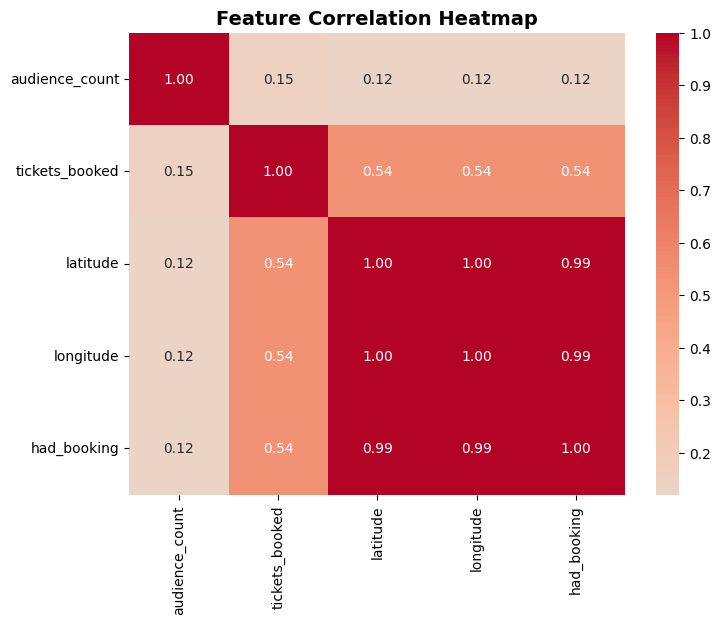

In [104]:
corr = final_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()

#### There is no one single feature which has strong correlation with the audience_count , it can be beacuse it may depend on multiple various factors(e.g time, seasonal effects , past patterns  etc.)

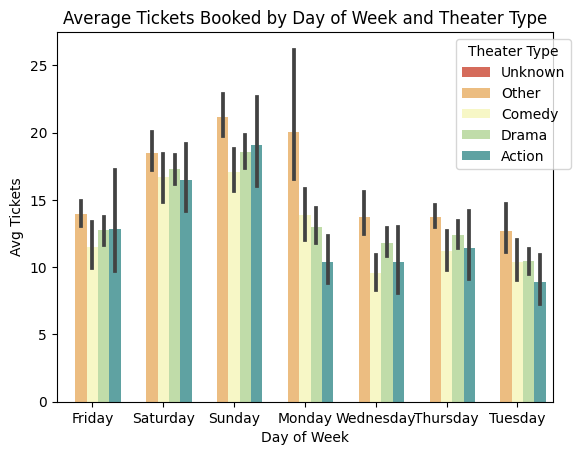

In [105]:
sns.barplot(data=final_df, x='day_of_week', y='tickets_booked', 
            estimator='mean', hue='theater_type', palette='Spectral')
plt.title("Average Tickets Booked by Day of Week and Theater Type")
plt.xlabel("Day of Week")
plt.ylabel("Avg Tickets")
plt.legend(title="Theater Type", bbox_to_anchor=(1.05, 1))
plt.show()

#### We can notice higher weeekend effect along with theater_type feature , even there is multiple features interaction, thats why we would need date features to capture more .

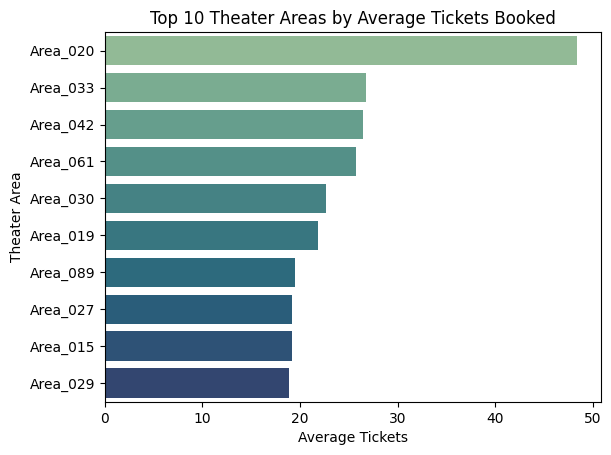

In [106]:
area_stats = final_df.groupby('theater_area')['tickets_booked'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=area_stats.values, y=area_stats.index, palette='crest')
plt.title("Top 10 Theater Areas by Average Tickets Booked")
plt.xlabel("Average Tickets")
plt.ylabel("Theater Area")
plt.show()


#### The patterns of audience and booking differ sharply by the geographical feature , it looks out for having theater_area and latitude and longitude for predictions.

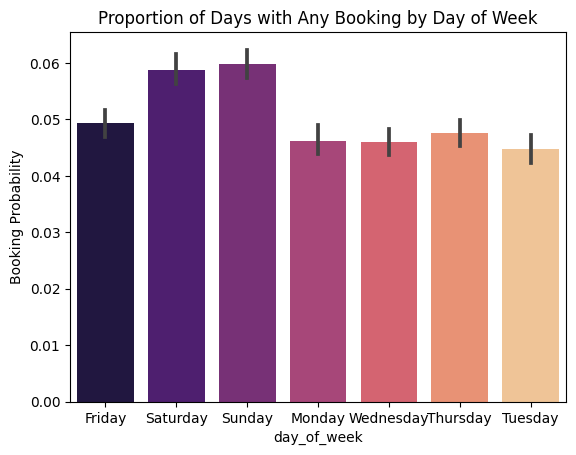

In [107]:
sns.barplot(data=final_df, x='day_of_week', y='had_booking', estimator='mean', palette='magma')
plt.title("Proportion of Days with Any Booking by Day of Week")
plt.ylabel("Booking Probability")
plt.show()


#### This chart would support the time functionality features , beacuse audinece counts are driven by weekly seasonality.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='audience_count', ylabel='Count'>

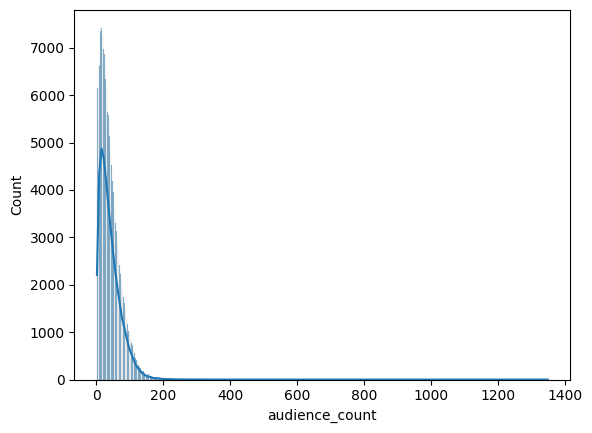

In [108]:
sns.histplot(final_df['audience_count'], kde=True)

#### The target variable audience_count is heavily right skewed with a long tail , which means that some days have unusual spikes , this kidn of distribution will make difficult for linear models, calibration and bias correction would make it handle the extreme values .

# Statistical Analysis

In [109]:
final_df[['audience_count','tickets_booked']].describe()

,audience_count,tickets_booked
count,214046.000000,214046.000000
mean,41.616568,0.776838
std,32.834918,6.253198
min,2.000000,0.000000
25%,18.000000,0.000000
50%,34.000000,0.000000
75%,58.000000,0.000000
max,1350.000000,1633.000000


#### audience_count which is the target variable is highly skewed with spikes , so the linear models will struggle. we can create log, rolling features to handle this. Also the tickets_booked coorelates weakly with the audience_count because most rows have 0 booking.


In [110]:
final_df.groupby('day_of_week')['audience_count'].mean()

day_of_week
Friday       37.626460
Monday       47.623494
Saturday     45.244812
Sunday       51.713413
Thursday     37.992760
Tuesday      35.039099
Wednesday    35.220707
Name: audience_count, dtype: float64

#### we can infer from the mean counts that the weekends tend to have higher audience counts .

In [111]:
final_df.groupby('theater_type')['audience_count'].mean()

theater_type
Action     62.576985
Comedy     60.375182
Drama      53.567323
Other      60.621584
Unknown    40.703435
Name: audience_count, dtype: float64

#### different theater_type have meaningful impact on the audience_count . Because different theater types attract different audiences .

In [112]:
final_df['audience_count'].std(), final_df['audience_count'].var()

(32.83491752296652, 1078.131808740014)

#### there is a lot of variance in the target variable, suggests that audience counts are not stable . And the standard deviation tells us that the count varies a lot from day to day, and which strongly puts the fact that the data is highly non-linear.

<Axes: >

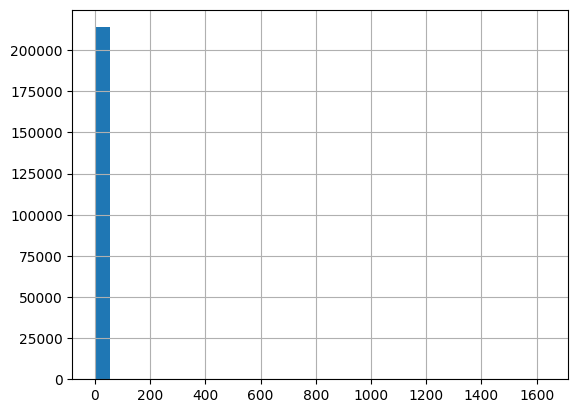

In [113]:
final_df['tickets_booked'].hist(bins=30)

#### Almost all the values near to 0 , which suggests that the fetaure is highly zero inflated , which also tells that this feature is not enough to be reliable to predict audience counts.


In [114]:
final_df['theater_type'].value_counts()

theater_type
Unknown    203180
Other        5782
Drama        3097
Comedy       1370
Action        617
Name: count, dtype: int64

In [115]:
final_df['theater_area'].value_counts().iloc[:10]

theater_area
Unknown     203180
Area_016       830
Area_008       825
Area_003       679
Area_010       604
Area_015       577
Area_001       548
Area_005       471
Area_006       467
Area_019       386
Name: count, dtype: int64

In [116]:
final_df['day_of_week'].value_counts()

day_of_week
Saturday     33875
Sunday       33079
Friday       31927
Thursday     30940
Wednesday    30656
Tuesday      27264
Monday       26305
Name: count, dtype: int64

# Feature Engineering

#### I created new features to help model pick up the time and theater behaviour, for that i added date-based features , also added cyclic encodings so the model can learn periodic trends, then included time-series features to capture the recent audience and booking history . 


In [117]:
final_df['show_date'] = pd.to_datetime(final_df['show_date'])

In [118]:
final_df['month'] = final_df['show_date'].dt.month

In [119]:
final_df['day'] = final_df['show_date'].dt.day

In [120]:
final_df['weekofyear'] = final_df['show_date'].dt.isocalendar().week.astype(int)

In [121]:
final_df['is_weekend'] = final_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

In [122]:
final_df = final_df.sort_values(by="show_date").reset_index(drop=True)
final_df['theater_activity'] = final_df.groupby('book_theater_id').cumcount()

In [123]:
final_df['quarter'] = final_df['show_date'].dt.quarter

In [124]:
final_df['sin_day'] = np.sin(2 * np.pi * final_df['day'] / 31)
final_df['cos_day'] = np.cos(2 * np.pi * final_df['day'] / 31)
final_df['sin_month'] = np.sin(2 * np.pi * final_df['month'] / 12)
final_df['cos_month'] = np.cos(2 * np.pi * final_df['month'] / 12)

In [125]:
final_df['lag_1'] = final_df.groupby('book_theater_id')['tickets_booked'].shift(1)  
final_df['roll_7'] = final_df.groupby('book_theater_id')['tickets_booked'].shift(1).rolling(7, min_periods=1).mean().reset_index(level=0, drop=True) 
final_df['days_since_prev'] = final_df.groupby('book_theater_id')['show_date'].diff().dt.days.fillna(999) 

In [126]:
final_df['lag_2'] = final_df.groupby('book_theater_id')['tickets_booked'].shift(2)

In [127]:
final_df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,book_theater_id,show_date,audience_count,tickets_booked,theater_type,theater_area,latitude,longitude,day_of_week,had_booking,...,theater_activity,quarter,sin_day,cos_day,sin_month,cos_month,lag_1,roll_7,days_since_prev,lag_2
0,book_00140,2023-01-01,22,0,Unknown,Unknown,0.0,0.0,Sunday,0,...,0,1,0.201299,0.97953,0.5,0.866025,NaN,NaN,999.0,NaN
1,book_00463,2023-01-01,24,0,Unknown,Unknown,0.0,0.0,Sunday,0,...,0,1,0.201299,0.97953,0.5,0.866025,NaN,NaN,999.0,NaN
2,book_00812,2023-01-01,8,0,Unknown,Unknown,0.0,0.0,Sunday,0,...,0,1,0.201299,0.97953,0.5,0.866025,NaN,NaN,999.0,NaN
3,book_00437,2023-01-01,32,0,Unknown,Unknown,0.0,0.0,Sunday,0,...,0,1,0.201299,0.97953,0.5,0.866025,NaN,NaN,999.0,NaN
4,book_00414,2023-01-01,14,0,Unknown,Unknown,0.0,0.0,Sunday,0,...,0,1,0.201299,0.97953,0.5,0.866025,NaN,NaN,999.0,NaN


# Train Validation splitting

#### I applied time based splitting of train and validation sets , instead of normal/ usual train test split because the dataset contains the dates , which will help not to leak the data . So this also will ensure that the model will predict the future from the past.

In [128]:
final_df["show_date"] = pd.to_datetime(final_df["show_date"])
final_df = final_df.sort_values(by="show_date").reset_index(drop=True)
X = final_df.drop(columns=["audience_count"])
y = final_df["audience_count"]
split_index = int(0.8 * len(final_df))
X_train, X_val = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_val = y.iloc[:split_index], y.iloc[split_index:]

print("Time-based split completed")

Time-based split completed


# Preprocessing 

#### In the whole preprocessing steps i did is to sepearte out the numerical and categorical column first , handled the missing values , applied labelencoding for the categorical features and then scaled numerical columns using a pipeline, then i wrapped up the preprocessor into ColumnTransformer to keep the consistency in both train and validation sets .

In [129]:
X_train = X_train.copy()
X_val = X_val.copy()

numeric_features = [
    "tickets_booked", "latitude", "longitude", "theater_activity",
    "month", "day", "weekofyear", "is_weekend", "had_booking", "quarter",
    "sin_day", "cos_day", "sin_month", "cos_month",
    "lag_1", "roll_7", "days_since_prev"
]
categorical_features = ["book_theater_id", "theater_type", "theater_area", "day_of_week"]

In [130]:
for col in categorical_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_val[col] = X_val[col].fillna("Unknown").astype(str)

In [131]:
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    full_categories = pd.concat([X_train[col], X_val[col]]).unique()
    le.fit(full_categories)
    X_train[col + '_encoded'] = le.transform(X_train[col])
    X_val[col + '_encoded'] = le.transform(X_val[col])
    label_encoders[col] = le 

encoded_categorical_features = [col + '_encoded' for col in categorical_features]

In [132]:
all_features_to_transform = numeric_features + encoded_categorical_features

# Defining numeric pipeline that impute missing values then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Combine numeric and categorical handling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='passthrough'  # keeps encoded categorical features
)
X_train_transformed_scaled = preprocessor.fit_transform(X_train[all_features_to_transform])
X_val_transformed_scaled = preprocessor.transform(X_val[all_features_to_transform])


categorical_indices = list(range(
    len(numeric_features),
    len(numeric_features) + len(encoded_categorical_features)
))

# Model Building

In [133]:
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train_transformed_scaled,y_train)

y_pred_lr = lr.predict(X_val_transformed_scaled)
mse_lr = mean_squared_error(y_val,y_pred_lr)
mae_lr = mean_absolute_error(y_val,y_pred_lr)
rmse_lr = mean_squared_error(y_val, y_pred_lr, squared=False)
print('Linear Regression R2 score :',r2_score(y_val,y_pred_lr))
print('Linear Regression MSE score :',mse_lr)
print('Linear Regression MAE score :', mae_lr)
print("Linear Regression RMSE :", rmse_lr)

Linear Regression R2 score : -0.20736672359526387
Linear Regression MSE score : 1225.825091173366
Linear Regression MAE score : 23.852454665169102
Linear Regression RMSE : 35.011785032662445


In [134]:
ridge = Ridge()
ridge.fit(X_train_transformed_scaled,y_train)
y_pred_ridge = ridge.predict(X_val_transformed_scaled)
mse_ridge = mean_squared_error(y_val,y_pred_ridge)
mae_ridge = mean_absolute_error(y_val,y_pred_ridge)
rmse_ridge = mean_squared_error(y_val,y_pred_ridge, squared=False)

print('Ridge R2 score:', r2_score(y_val, y_pred_ridge))
print('Ridge MSE score :',mse_ridge)
print('Ridge MAE score :',mae_ridge)
print("Ridge RMSE :",rmse_ridge)

Ridge R2 score: -0.20733035332719063
Ridge MSE score : 1225.7881648722632
Ridge MAE score : 23.852334534301114
Ridge RMSE : 35.011257687667594


In [135]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,          
    verbose=0
)

rf.fit(X_train_transformed_scaled,y_train)
y_pred_rf = rf.predict(X_val_transformed_scaled)
mse_rf = mean_squared_error(y_val,y_pred_rf)
mae_rf = mean_absolute_error(y_val,y_pred_rf)
rmse_rf = mean_squared_error(y_val,y_pred_rf, squared=False)

print('Random Forest R2 score:',r2_score(y_val,y_pred_rf))
print('Random Forest MSE score :',mse_rf)
print('Random Forest MAE score :',mae_rf)
print("Random Forest RMSE :",rmse_rf)

Random Forest R2 score: 0.09040592625233179
Random Forest MSE score : 923.5000572669937
Random Forest MAE score : 22.692711516000934
Random Forest RMSE : 30.38914374027333


In [136]:
dt_model = DecisionTreeRegressor(
    max_depth=10,        
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train_transformed_scaled, y_train)
y_pred_dt = dt_model.predict(X_val_transformed_scaled)
mse_dt = mean_squared_error(y_val,y_pred_dt)
mae_dt = mean_absolute_error(y_val,y_pred_dt)
rmse_dt = mean_squared_error(y_val,y_pred_dt, squared=False)

print("Decision Tree R2 score:", r2_score(y_val, y_pred_dt))
print('Decision Tree MSE score :',mse_dt)
print('Decision Tree MAE score :',mae_dt)
print("Decision Tree RMSE :",rmse_dt)

Decision Tree R2 score: 0.11153129164265263
Decision Tree MSE score : 902.0517247516265
Decision Tree MAE score : 22.900327040481063
Decision Tree RMSE : 30.034175945939094


In [137]:
lgb_model = lgb.LGBMRegressor(
    objective='mae',
    metric='mae',
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=63,
    min_child_samples=200,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.7,
    lambda_l1=2.0,
    lambda_l2=2.0,
    random_state=42,
    verbose=-1 
)

lgb_model.fit(
    X_train_transformed_scaled,
    y_train,
    eval_set=[(X_val_transformed_scaled, y_val)],
    eval_metric='l2',
    callbacks=[lgb.early_stopping(stopping_rounds=200)],
    categorical_feature=categorical_indices
)

y_pred_lgb = lgb_model.predict(X_val_transformed_scaled)
r2_lgb = r2_score(y_val, y_pred_lgb)
mse_lgb = mean_squared_error(y_val, y_pred_lgb)
rmse_lgb = mean_squared_error(y_val, y_pred_lgb, squared=False)
mae_lgb = mean_absolute_error(y_val, y_pred_lgb)

print("LightGBM R2 score:", r2_score(y_val, y_pred_lgb))
print('LightGBM MSE score :', mse_lgb)
print('LightGBM RMSE score:', rmse_lgb)
print("LightGBM MAE score:", mae_lgb)

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2749]	valid_0's l2: 510.741	valid_0's l1: 15.5097
LightGBM R2 score: 0.49694988649247285
LightGBM MSE score : 510.7408041020781
LightGBM RMSE score: 22.59957530800254
LightGBM MAE score: 15.509682201510303


In [138]:
# base_lgb = lgb.LGBMRegressor(
#     objective='regression',
#     metric='l2',
#     random_state=42,
#     n_jobs=-1
# )

# param_dist = {
#     "num_leaves": [31, 63],
#     "learning_rate": [0.005, 0.01],
#     "max_depth": [6],
#     "n_estimators": [800, 1200]
# }

# tuner = RandomizedSearchCV(
#     estimator=base_lgb,
#     param_distributions=param_dist,
#     n_iter=2,       
#     scoring='r2',
#     cv=2,           
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# tuner.fit(X_train_transformed_scaled, y_train)

# print("Best Parameters:", tuner.best_params_)
# print("Best R2 Score:", tuner.best_score_)


#### The HPT didn't produced better results then the without tuned LightGBM model because the data is non-linear and this gave me explored parameter ranges.

# Model comparison

In [139]:
model_results = pd.DataFrame({
    'Models': ['Linear Regression', 'Ridge', 'Decision Tree','Random Forest','LightGBM'],
    'R2 Score':[r2_score(y_val,y_pred_lr),r2_score(y_val, y_pred_ridge),r2_score(y_val, y_pred_dt),r2_score(y_val,y_pred_rf), r2_score(y_val, y_pred_lgb)],
    'MSE':[mse_lr, mse_ridge, mse_dt, mse_rf, mse_lgb],
    'RMSE':[rmse_lr, rmse_ridge, rmse_dt, rmse_rf, rmse_lgb],
    'MAE': [mae_lr, mae_ridge, mae_dt, mae_rf, mae_lgb]
})

model_results

,Models,R2 Score,MSE,RMSE,MAE
0,Linear Regression,-0.207367,1225.825091,35.011785,23.852455
1,Ridge,-0.207330,1225.788165,35.011258,23.852335
2,Decision Tree,0.111531,902.051725,30.034176,22.900327
3,Random Forest,0.090406,923.500057,30.389144,22.692712
4,LightGBM,0.496950,510.740804,22.599575,15.509682


#### I compared this 5 models against each other and we could infer that the linear models are performing relatively weak which confirms the fact that the data is non-linear , while Tree based models outperformed them , but the LightGBM model gave us the highest R2 score and lowest RMSE and MAE among these models . Therfore the final choice of model was LightGBM

# Submission code 

In [140]:
# --- Final Submission ---

# Using best iteration from LightGBM training (not dynamic)
OPTIMAL_N_ESTIMATORS = lgb_model.best_iteration_

# Load sample submission
sample_submission = pd.read_csv("../input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

# Extract theater_id and date from ID
def extract_parts(x):
    t, d = x.rsplit("_", 1)
    return t, d

sample_submission[["book_theater_id", "date"]] = sample_submission["ID"].apply(lambda x: pd.Series(extract_parts(x)))
sample_submission["show_date"] = pd.to_datetime(sample_submission["date"])
sample_submission.drop(columns=["date"], inplace=True)

# Basic feature engineering (same as training)
sample_submission["tickets_booked"] = 0
sample_submission["month"] = sample_submission["show_date"].dt.month
sample_submission["day"] = sample_submission["show_date"].dt.day
sample_submission["weekofyear"] = sample_submission["show_date"].dt.isocalendar().week.astype(int)
sample_submission["quarter"] = sample_submission["show_date"].dt.quarter
sample_submission["day_of_week"] = sample_submission["show_date"].dt.day_name()
sample_submission["is_weekend"] = sample_submission["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Cyclic features
sample_submission["sin_day"] = np.sin(2*np.pi*sample_submission["day"]/31)
sample_submission["cos_day"] = np.cos(2*np.pi*sample_submission["day"]/31)
sample_submission["sin_month"] = np.sin(2*np.pi*sample_submission["month"]/12)
sample_submission["cos_month"] = np.cos(2*np.pi*sample_submission["month"]/12)

# --- Theater-level info (last known values) ---
last_info = final_df.sort_values("show_date").groupby("book_theater_id").last()

# 1. Map the static columns (Type, Area, Lat, Lon, etc.)
to_map = ["theater_type", "theater_area", "latitude", "longitude", "had_booking", "theater_activity"]
for col in to_map:
    sample_submission[col] = sample_submission["book_theater_id"].map(last_info[col])

# 2. Handle the Date separately to avoid overwriting the current 'show_date'
# We map the last known date to a NEW column: 'show_date_last'
sample_submission["show_date_last"] = sample_submission["book_theater_id"].map(last_info["show_date"])

# 3. Calculate the difference
sample_submission["days_since_prev"] = (sample_submission["show_date"] - sample_submission["show_date_last"]).dt.days.fillna(999)

# 4. Clean up (optional, removing the helper column)
sample_submission.drop(columns=["show_date_last"], inplace=True)

# --- Handle missing values in theater info ---
sample_submission["theater_type"] = sample_submission["theater_type"].fillna("Unknown")
sample_submission["theater_area"] = sample_submission["theater_area"].fillna("Unknown")
sample_submission["latitude"] = sample_submission["latitude"].fillna(final_df["latitude"].mean())
sample_submission["longitude"] = sample_submission["longitude"].fillna(final_df["longitude"].mean())
sample_submission["had_booking"] = sample_submission["had_booking"].fillna(0)
sample_submission["theater_activity"] = sample_submission["theater_activity"].fillna(0)

# Add roll_7 baseline
roll7 = final_df.groupby("book_theater_id")["audience_count"].rolling(7, min_periods=1).mean().groupby(level=0).last()
sample_submission["roll_7"] = sample_submission["book_theater_id"].map(roll7).fillna(10)
sample_submission["lag_1"] = 0

# Encode categorical columns
for col in categorical_features:
    le = label_encoders[col]
    
    if "Unknown" not in le.classes_:
        le.classes_ = np.append(le.classes_, "Unknown")
        
    sample_submission[col] = sample_submission[col].apply(lambda x: x if x in le.classes_ else "Unknown")
    sample_submission[col + "_encoded"] = le.transform(sample_submission[col])

# Final feature matrix
final_features = numeric_features + [c + "_encoded" for c in categorical_features]
X_test_prepared = preprocessor.transform(sample_submission[final_features])

# Raw model predictions
raw_pred = lgb_model.predict(X_test_prepared, num_iteration=OPTIMAL_N_ESTIMATORS)

# Calibration
val_pred = lgb_model.predict(X_val_transformed_scaled, num_iteration=OPTIMAL_N_ESTIMATORS)
cal = LinearRegression()
cal.fit(val_pred.reshape(-1,1), y_val)
calibrated = cal.predict(raw_pred.reshape(-1,1))

# Theater-level bias correction
val_df = X_val.copy()
val_df["y_true"] = y_val.values
val_df["y_pred"] = val_pred
val_df["resid"] = val_df["y_true"] - val_df["y_pred"]

bias = val_df.groupby("book_theater_id")["resid"].mean()
sample_bias = sample_submission["book_theater_id"].map(bias).fillna(0)
bias_corrected = calibrated + 0.4 * sample_bias.values

# Blend with baseline
final_pred = 0.9 * bias_corrected + 0.1 * sample_submission["roll_7"]
final_pred = np.clip(final_pred, 0, None)
final_pred = final_pred.round().astype(int)

# Save submission
submission = pd.DataFrame({
    "ID": sample_submission["ID"],
    "audience_count": final_pred
})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved")


submission.csv saved


In [141]:
# # Use the best boosting round
# if hasattr(lgb_model, "booster_") and lgb_model.booster_.best_iteration > 0:
#     OPTIMAL_N_ESTIMATORS = lgb_model.booster_.best_iteration
# else:
#     OPTIMAL_N_ESTIMATORS = 2000

# print("Using OPTIMAL_N_ESTIMATORS:", OPTIMAL_N_ESTIMATORS)

# # Load submission file
# sample_submission = pd.read_csv(
#     "/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv"
# )

# # Extract theater id and date from ID
# def extract_parts(x):
#     parts = x.split("_")
#     return "_".join(parts[:2]), parts[2]

# sample_submission[["book_theater_id", "date_str"]] = (
#     sample_submission["ID"].apply(lambda x: pd.Series(extract_parts(x)))
# )
# sample_submission["show_date"] = pd.to_datetime(sample_submission["date_str"], errors="coerce")
# sample_submission.drop(columns=["date_str"], inplace=True)

# # Basic feature construction for test data
# sample_submission["tickets_booked"] = 0.0

# theater_roll_7_last = (
#     final_df.sort_values(["book_theater_id", "show_date"])
#             .groupby("book_theater_id")["audience_count"]
#             .apply(lambda x: x.rolling(7, min_periods=1).mean().iloc[-1])
# )

# sample_submission["lag_1"] = 0.0
# sample_submission["roll_7"] = sample_submission["book_theater_id"].map(theater_roll_7_last).fillna(10)

# sample_submission["month"] = sample_submission["show_date"].dt.month.fillna(0).astype(int)
# sample_submission["day"] = sample_submission["show_date"].dt.day.fillna(0).astype(int)
# sample_submission["weekofyear"] = sample_submission["show_date"].dt.isocalendar().week.astype(int)
# sample_submission["quarter"] = sample_submission["show_date"].dt.quarter.astype(int)
# sample_submission["day_of_week"] = sample_submission["show_date"].dt.day_name().fillna("Unknown")
# sample_submission["is_weekend"] = sample_submission["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# # Cyclic encodings
# sample_submission["sin_day"] = np.sin(2 * np.pi * sample_submission["day"] / 31)
# sample_submission["cos_day"] = np.cos(2 * np.pi * sample_submission["day"] / 31)
# sample_submission["sin_month"] = np.sin(2 * np.pi * sample_submission["month"] / 12)
# sample_submission["cos_month"] = np.cos(2 * np.pi * sample_submission["month"] / 12)

# # Map last known theater-level info
# last_info = final_df.groupby("book_theater_id").agg({
#     "theater_type": "last",
#     "theater_area": "last",
#     "latitude": "last",
#     "longitude": "last",
#     "had_booking": "last",
#     "show_date": "max",
#     "theater_activity": "last"
# })

# for col in ["theater_type", "theater_area"]:
#     sample_submission[col] = (sample_submission["book_theater_id"].map(last_info[col]).fillna("Unknown"))

# for col in ["latitude", "longitude"]:
#     sample_submission[col] = (sample_submission["book_theater_id"].map(last_info[col]).fillna(final_df[col].mean()))

# for col in ["had_booking", "theater_activity"]:
#     sample_submission[col] = (sample_submission["book_theater_id"].map(last_info[col]).fillna(0))

# sample_submission["days_since_prev"] = (sample_submission["show_date"] -sample_submission["book_theater_id"].map(last_info["show_date"])).dt.days.fillna(999)

# # Encode categorical variables
# categorical_features = ["book_theater_id", "theater_type", "theater_area", "day_of_week"]
# for col in categorical_features:
#     le = label_encoders[col]
#     if "Unknown" not in le.classes_:
#         le.classes_ = np.append(le.classes_, "Unknown")
#     sample_submission[col] = sample_submission[col].astype(str).apply(
#         lambda x: x if x in le.classes_ else "Unknown"
#     )
#     sample_submission[col + "_encoded"] = le.transform(sample_submission[col])

# encoded_categorical_features = [c + "_encoded" for c in categorical_features]


# numeric_features = [
#     "tickets_booked", "latitude", "longitude", "theater_activity",
#     "month", "day", "weekofyear", "is_weekend", "had_booking", "quarter",
#     "sin_day", "cos_day", "sin_month", "cos_month",
#     "lag_1", "roll_7", "days_since_prev"
# ]

# feature_cols = numeric_features + encoded_categorical_features

# # Model predictions
# X_test_transformed = preprocessor.transform(sample_submission[feature_cols])
# y_pred_test = lgb_model.predict(X_test_transformed,num_iteration=OPTIMAL_N_ESTIMATORS)

# # Calibration model based on validation predictions
# y_val_pred_model = lgb_model.predict(X_val_transformed_scaled,num_iteration=int(getattr(lgb_model, "best_iteration_", None) or lgb_model.n_estimators))

# cal = LinearRegression()
# cal.fit(y_val_pred_model.reshape(-1, 1), y_val.values)
# a, b = cal.coef_[0], cal.intercept_
# print(f"Calibration fitted on validation: y = {a:.4f} * pred + {b:.4f}")

# y_test_cal = cal.predict(y_pred_test.reshape(-1, 1))

# # Theater-level bias correction based on validation residuals 
# val_meta = X_val.copy().reset_index(drop=True)
# val_meta["y_true"] = y_val.values
# val_meta["y_pred"] = y_val_pred_model
# val_meta["resid"] = val_meta["y_true"] - val_meta["y_pred"]

# per_theater_bias = val_meta.groupby("book_theater_id")["resid"].mean()

# theater_ids = sample_submission["book_theater_id"].values
# mapped_bias = np.array([per_theater_bias.get(tid, 0.0) for tid in theater_ids])

# mapped_bias_shrunk = mapped_bias * 0.40

# y_test_cal_bias = y_test_cal + mapped_bias_shrunk

# # mild blending with roll_7 baseline
# if "roll_7" in sample_submission.columns:
#     baseline_vals = sample_submission["roll_7"].values
# else:
#     baseline_vals = np.zeros(len(y_test_cal_bias))

# y_final = 0.90 * y_test_cal_bias + 0.10 * baseline_vals

# # Final clipping
# y_final = np.clip(y_final, 0, None)
# y_final = np.round(y_final).astype(int)

# # Save submission file
# submission_path = "/kaggle/working/submission.csv"
# pd.DataFrame({
#     "ID": sample_submission["ID"],
#     "audience_count": y_final
# }).to_csv(submission_path, index=False)

# print("Submission saved at:", submission_path)